In [1]:
# ============================================================
#  Concave partitions — everything concave_hull(lam, plot=False) needs.
#  (Plotting helpers _plot_partition / plot_all are omitted: not reached
#   when plot=False.)
# ============================================================

try:
    from sage.all import Polyhedron
except ImportError:
    from sage.geometry.polyhedron.constructor import Polyhedron


# ── helpers ─────────────────────────────────────────────────

def _row_len(lam, r):
    r = int(r)
    if 1 <= r <= len(lam):
        return int(lam[r - 1])
    return 0

def _in_lam(lam, c, r):
    c, r = int(c), int(r)
    if not (1 <= r <= len(lam)):
        return False
    return 1 <= c <= int(lam[r - 1])

def _touches8(lam, c, r):
    c, r = int(c), int(r)
    for dc in [-1, 0, 1]:
        for dr in [-1, 0, 1]:
            if dc == 0 and dr == 0:
                continue
            if _in_lam(lam, c + dc, r + dr):
                return True
    return False

def _qualifying_boxes(lam):
    max_col = int(max(lam)) + 3
    max_row = int(len(lam)) + 3
    result = []
    for c in range(2, max_col + 1):
        for r in range(2, max_row + 1):
            if not _in_lam(lam, c, r) and not _touches8(lam, c, r):
                result.append((c, r))
    result.sort()
    return result

def _finite_vertices(lam):
    """
    Return (finite_verts, ll_ieqs) for the unbounded convex hull.

    Sage inequality [b, a0, a1] means a0*x + a1*y + b >= 0.
    Outward normal of the feasible region is (-a0, -a1).
    Lower-left-facing facet (outward normal points SW): a0 > 0 and a1 > 0.

    ll_ieqs entries are (a0, a1, b) with a0*x + a1*y + b >= 0, a0 > 0, a1 > 0.
    """
    cands = _qualifying_boxes(lam)
    if not cands:
        return [], []

    ll_corners = list(set((c - 1, r - 1) for c, r in cands))
    P = Polyhedron(vertices=ll_corners)

    ll_ieqs = []
    for ieq in P.inequalities():
        b  = QQ(ieq[0])
        a0 = QQ(ieq[1])
        a1 = QQ(ieq[2])
        if a0 > 0 and a1 > 0:          # <-- lower-left-facing: outward normal (-a0,-a1) is SW
            ll_ieqs.append((a0, a1, b))

    finite_verts = set()
    for v in P.vertices():
        x = QQ(v[0])
        y = QQ(v[1])
        for (a0, a1, b) in ll_ieqs:
            if a0 * x + a1 * y + b == 0:
                finite_verts.add((x, y))
                break

    finite_verts = sorted((ZZ(x), ZZ(y)) for x, y in finite_verts)
    return finite_verts, ll_ieqs

def _in_hull(ll_ieqs, x, y):
    """
    True iff (x, y) is in the unbounded hull (boundary included).
    The unbounded hull satisfies exactly the lower-left-facing constraints.
    """
    x, y = QQ(x), QQ(y)
    for (a0, a1, b) in ll_ieqs:
        if a0 * x + a1 * y + b < 0:
            return False
    return True


def _boundary_curve(finite_verts):
    """
    Boundary polyline of the unbounded hull, ordered y-axis -> x-axis.

    Returns (curve, y_left, x_bot) where curve is a list of (QQ, QQ)
    points: the y-axis intercept, the finite vertices, then the x-axis
    intercept.  The first/last facets are extended to the axes.
    """
    v = [(QQ(x), QQ(y)) for x, y in finite_verts]
    if len(v) >= 2:
        m0     = (v[1][1] - v[0][1]) / (v[1][0] - v[0][0])
        y_left = v[0][1] - m0 * v[0][0]                                   # hits x = 0
        m_last = (v[-1][1] - v[-2][1]) / (v[-1][0] - v[-2][0])
        x_bot  = v[-1][0] - v[-1][1] / m_last if m_last != 0 else v[-1][0]  # hits y = 0
    else:
        # single hull vertex: the boundary is a right-angle corner
        y_left = v[0][1]
        x_bot  = v[0][0]
    return [(QQ(0), y_left)] + v + [(x_bot, QQ(0))], y_left, x_bot


# ── main function ────────────────────────────────────────────

def concave_hull(lam, plot=True, size=1, verbose=True):
    """
    Analyze a partition and, if plot=True, draw and display it.

    Computes the unbounded convex hull of the qualifying outside boxes,
    its boundary curve (y-axis -> x-axis), and whether lam is concave.

    Returns a details dict carrying everything the overlay needs:
        lam          : the partition (list)
        is_concave   : bool, or None when there are no qualifying boxes
        finite_verts : finite vertices of the hull
        ll_ieqs      : lower-left-facing inequalities (a0, a1, b)
        curve        : boundary polyline [(QQ, QQ), ...], y-axis -> x-axis
                       ([] when there are no qualifying boxes)
        y_left, x_bot: where the curve meets the y- and x-axes (or None)
        plot         : Graphics object, or None when plot=False

    With plot=True the figure is shown immediately; the details dict is
    still returned (assign it, e.g. d = concave_hull(...), to keep it
    without echoing the dict).
    """
    lam = list(lam)
    details = dict(lam=lam, is_concave=None, finite_verts=[], ll_ieqs=[],
                   curve=[], y_left=None, x_bot=None, plot=None)

    if not lam:
        if verbose:
            print("Empty partition.")
        return details

    finite_verts, ll_ieqs = _finite_vertices(lam)
    details['finite_verts'] = finite_verts
    details['ll_ieqs']      = ll_ieqs

    if finite_verts:
        # boundary curve
        curve, y_left, x_bot = _boundary_curve(finite_verts)
        details.update(curve=curve, y_left=y_left, x_bot=x_bot)

        # boxes of lam (French notation)
        lam_boxes = []
        for r in range(1, len(lam) + 1):
            for c in range(1, _row_len(lam, r) + 1):
                lam_boxes.append((c, r))

        # concavity: lam is concave iff no lam box touches the hull
        is_concave, touch = True, None
        for (c, r) in lam_boxes:
            test_pts = [
                (c - 1, r - 1), (c, r - 1), (c, r), (c - 1, r),
                (QQ(2*c - 1) / 2, QQ(2*r - 1) / 2),
            ]
            hit = next((pt for pt in test_pts if _in_hull(ll_ieqs, pt[0], pt[1])), None)
            if hit is not None:
                is_concave, touch = False, (c, r, hit)
                break
        details['is_concave'] = is_concave

        if verbose:
            if is_concave:
                print("Partition {} is concave.".format(lam))
                print("Finite vertices of the unbounded convex hull: {}".format(finite_verts))
            else:
                c, r, pt = touch
                print("{} is not concave!  (box ({},{}) touches the hull at {})".format(
                    lam, c, r, pt))
    elif verbose:
        print("{} : no qualifying boxes found.".format(lam))

    if plot:                              # plot=True builds AND displays the figure
        details['plot'] = _plot_partition(details, size=size)
        details['plot'].show()

    return details


# ── plotting ─────────────────────────────────────────────────

def _plot_partition(details, size=1):
    """
    Draw the Young diagram, qualifying boxes, shaded unbounded hull with
    its boundary curve, and the finite vertices.  Returns a Graphics
    object (does not display it).  Driven by a details dict from
    concave_hull.
    """
    S            = size
    lam          = details['lam']
    finite_verts = details['finite_verts']
    curve        = details['curve']
    y_left_val   = details['y_left']
    x_bot_val    = details['x_bot']
    not_concave  = details['is_concave'] is False

    lam_fill = '#F7C1C1' if not_concave else '#B5D4F4'
    lam_edge = '#E24B4A' if not_concave else '#378ADD'
    h_fill   = '#FCEBEB' if not_concave else '#EEEDFE'
    h_edge   = '#A32D2D' if not_concave else '#534AB7'
    v_col    = '#A32D2D' if not_concave else '#534AB7'

    def _fmt(q):
        q = QQ(q)
        return str(int(q)) if q.denominator() == 1 else \
            '{}/{}'.format(int(q.numerator()), int(q.denominator()))

    lam_boxes = []
    for r in range(1, len(lam) + 1):
        for c in range(1, _row_len(lam, r) + 1):
            lam_boxes.append((c, r))

    G = Graphics()

    # hull shaded region and boundary curve
    if curve:
        large    = (max(int(max(lam)), int(len(lam))) + 5) * S
        curve_xy = [(float(x) * S, float(y) * S) for x, y in curve]
        y_left   = float(y_left_val) * S
        x_bot    = float(x_bot_val) * S

        poly_pts = curve_xy + [(large, 0), (large, large), (0, large)]
        G += polygon2d(poly_pts, color=h_fill, alpha=0.5, zorder=1)
        G += line(curve_xy, color=h_edge, thickness=1.8, zorder=4)

    # qualifying boxes
    for (c, r) in _qualifying_boxes(lam):
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color='#F1EFE8', edgecolor='#B4B2A9', thickness=0.5, zorder=2
        )

    # lambda boxes
    for (c, r) in lam_boxes:
        x0 = (c - 1) * S
        y0 = (r - 1) * S
        G += polygon2d(
            [(x0, y0), (x0+S, y0), (x0+S, y0+S), (x0, y0+S)],
            color=lam_fill, edgecolor=lam_edge, thickness=0.8, zorder=3
        )

    # finite vertices (interior only) + axis intersection points
    if curve:
        for (x, y) in finite_verts[1:-1]:
            xi, yi = int(x), int(y)
            G += point((xi*S, yi*S), color=v_col, size=30, zorder=6)
            G += text(
                '({},{})'.format(xi, yi),
                (xi*S + 0.15*S, yi*S + 0.15*S),
                fontsize=8, color=v_col, zorder=7,
                horizontal_alignment='left'
            )
        G += point((0, y_left), color=v_col, size=30, zorder=6)
        G += text(
            '(0,{})'.format(_fmt(y_left_val)),
            (-0.15*S, y_left),
            fontsize=8, color=v_col, zorder=7,
            horizontal_alignment='right'
        )
        G += point((x_bot, 0), color=v_col, size=30, zorder=6)
        G += text(
            '({},0)'.format(_fmt(x_bot_val)),
            (x_bot, -0.2*S),
            fontsize=8, color=v_col, zorder=7,
            horizontal_alignment='center'
        )

    # title
    title = 'lam = {}'.format(tuple(lam))
    if not_concave:
        title += '  -- not concave!'
    top_y = (max(int(len(lam)),
                 int(finite_verts[-1][1]) if finite_verts else 0) + 1) * S
    G += text(title, (0, top_y + 0.3*S),
              fontsize=10, color='black', zorder=7,
              horizontal_alignment='left')

    G.axes(True)
    G.set_aspect_ratio(1)
    return G


# ============================================================
#  Using Curve — arcs of the boundary curve overlaid onto [0,1]^2,
#  and the two boundary label walks.  (print_arcs / overlay_all are
#  omitted: not reached by perm / list1 / list2.)
# ============================================================

import math


# ── arcs from the curve ──────────────────────────────────────

def _grid_split(points):
    """
    Refine an x-monotone polyline by inserting every crossing with an
    integer grid line (x = k or y = k).  After this, each consecutive
    pair of points lies within a single unit square.
    """
    if not points:
        return []

    refined = [points[0]]
    for k in range(len(points) - 1):
        x0, y0 = points[k]
        x1, y1 = points[k + 1]
        ts = set()

        if x1 != x0:                                     # vertical grid lines
            lo = floor(min(x0, x1)) + 1
            hi = ceil(max(x0, x1)) - 1
            for xi in range(int(lo), int(hi) + 1):
                t = (QQ(xi) - x0) / (x1 - x0)
                if 0 < t < 1:
                    ts.add(t)

        if y1 != y0:                                     # horizontal grid lines
            lo = floor(min(y0, y1)) + 1
            hi = ceil(max(y0, y1)) - 1
            for yi in range(int(lo), int(hi) + 1):
                t = (QQ(yi) - y0) / (y1 - y0)
                if 0 < t < 1:
                    ts.add(t)

        for t in sorted(ts):
            refined.append((x0 + t * (x1 - x0), y0 + t * (y1 - y0)))
        refined.append((x1, y1))
    return refined


def _is_grid_pt(p):
    """True if p sits on an integer grid line (so it bounds a unit square)."""
    x, y = p
    return (QQ(x).denominator() == 1) or (QQ(y).denominator() == 1)


def curve_arcs(details):
    """
    Split details['curve'] into one arc per unit square it crosses and
    overlay the squares onto [0,1]^2.

    `details` is the dict returned by concave_hull.  Returns a list of
    arcs in curve order; each arc is a dict:
        index : 1-based position along the curve (top-left box = 1)
        cell  : (i, j) integer unit square [i,i+1] x [j,j+1] it came from
        local : the arc's points translated into [0,1]^2 (entry first)
        glob  : the arc's points in the original picture
    """
    pts = details['curve']
    if not pts:
        return []

    refined  = _grid_split(pts)
    grid_idx = [i for i, p in enumerate(refined) if _is_grid_pt(p)]

    arcs = []
    for n, (a, b) in enumerate(zip(grid_idx, grid_idx[1:]), start=1):
        seg = refined[a:b + 1]
        mx  = (seg[0][0] + seg[-1][0]) / 2               # chord midpoint -> cell
        my  = (seg[0][1] + seg[-1][1]) / 2
        i, j = int(floor(mx)), int(floor(my))
        arcs.append(dict(
            index=n,
            cell=(i, j),
            local=[(x - i, y - j) for x, y in seg],
            glob=seg,
        ))
    return arcs


def boundary_lists(details):
    """
    Read the arc labels along the two boundary walks of the overlaid unit
    square, each running from the bottom-left corner to the top-right one:

        via_tl : bottom-left -> top-left -> top-right
                 (up the left edge x=0, then across the top edge y=1)
        via_br : bottom-left -> bottom-right -> top-right
                 (across the bottom edge y=0, then up the right edge x=1)

    Each arc enters its unit square on the left/top edge (first point of
    arc['local']) and exits on the bottom/right edge (last point), so
    via_tl reads every label once (the entries) and via_br reads every
    label once (the exits).  Where several labels share a point the
    smaller one comes first; a corner is read on the first edge of its
    walk (top-left counts as left, bottom-right counts as bottom).
    """
    left, top, bottom, right = {}, {}, {}, {}
    for a in curve_arcs(details):
        ex, ey = a['local'][0]                 # entry endpoint
        if ex == 0:
            left.setdefault(ey, []).append(a['index'])
        elif ey == 1:
            top.setdefault(ex, []).append(a['index'])

        fx, fy = a['local'][-1]                # exit endpoint
        if fy == 0:
            bottom.setdefault(fx, []).append(a['index'])
        elif fx == 1:
            right.setdefault(fy, []).append(a['index'])

    def _flat(pts):                            # group keys ascending, smaller label first
        return [i for k in sorted(pts) for i in sorted(pts[k])]

    via_tl = _flat(left)   + _flat(top)        # left bottom->top, then top left->right
    via_br = _flat(bottom) + _flat(right)      # bottom left->right, then right bottom->top
    return via_tl, via_br


# ── plotting ─────────────────────────────────────────────────

def _outward(p):
    """Outward unit direction at a boundary point p of [0,1]^2 (for labels)."""
    x, y = p
    nx = -1 if x == 0 else (1 if x == 1 else 0)
    ny = -1 if y == 0 else (1 if y == 1 else 0)
    if nx == 0 and ny == 0:
        return (0.0, 1.0)
    norm = math.sqrt(float(nx) ** 2 + float(ny) ** 2)
    return (nx / norm, ny / norm)


def overlay_square(details, size=1):
    """
    The overlaid unit square: every unit square crossed by the curve
    folded onto [0,1]^2, with each arc numbered (at both endpoints) in the
    order it appears along the curve.  Returns a Graphics object.
    """
    S = size
    arcs = curve_arcs(details)
    lam  = details['lam']

    G = Graphics()
    G += polygon2d([(0, 0), (S, 0), (S, S), (0, S)],
                   color='white', edgecolor='#888888', thickness=1.2, zorder=1)

    if not arcs:
        G += text('{} : no curve'.format(tuple(lam)), (0.5*S, 0.5*S), color='gray')
        G.set_aspect_ratio(1); G.axes(False)
        return G

    cols = rainbow(len(arcs))

    # draw the arcs (overlaid; identical arcs land on top of one another)
    for a in arcs:
        c  = cols[a['index'] - 1]
        pl = [(float(x) * S, float(y) * S) for x, y in a['local']]
        G += line(pl, color=c, thickness=2.2, alpha=0.9, zorder=3)
        for end in (a['local'][0], a['local'][-1]):
            G += point((float(end[0]) * S, float(end[1]) * S), color=c, size=16, zorder=4)

    # label both endpoints of each arc; fan out labels that share a point
    ends = {}
    for a in arcs:
        for end in (a['local'][0], a['local'][-1]):
            ends.setdefault(end, []).append(a['index'])
    for p, idxs in ends.items():
        ox, oy = _outward(p)
        for m, idx in enumerate(sorted(idxs)):
            d  = 0.07 + 0.12 * m
            tx = (float(p[0]) + ox * d) * S
            ty = (float(p[1]) + oy * d) * S
            G += text(str(idx), (tx, ty), fontsize=11, color=cols[idx - 1], zorder=5)

    G += text('overlay: {}'.format(tuple(lam)), (0.5 * S, 1.32 * S),
              fontsize=11, color='black', zorder=5)
    G.set_aspect_ratio(1)
    G.axes(False)
    return G


def curve_grid_plot(details, size=1):
    """
    The source picture: the curve over the integer grid, with each unit
    square it crosses shaded and numbered by its order along the curve.
    Shown next to overlay_square to make the folding explicit.
    """
    S = size
    pts  = details['curve']
    arcs = curve_arcs(details)
    lam  = details['lam']

    G = Graphics()
    if not pts:
        return G

    xmax = int(ceil(max(x for x, _ in pts)))
    ymax = int(ceil(max(y for _, y in pts)))
    cols = rainbow(len(arcs))

    for i in range(xmax + 1):
        G += line([(i*S, 0), (i*S, ymax*S)], color='#dddddd', thickness=0.6, zorder=1)
    for j in range(ymax + 1):
        G += line([(0, j*S), (xmax*S, j*S)], color='#dddddd', thickness=0.6, zorder=1)

    for a in arcs:
        i, j = a['cell']
        G += polygon2d([(i*S, j*S), ((i+1)*S, j*S), ((i+1)*S, (j+1)*S), (i*S, (j+1)*S)],
                       color=cols[a['index'] - 1], alpha=0.25, zorder=2)
        G += text(str(a['index']), ((i + 0.5)*S, (j + 0.5)*S),
                  fontsize=10, color=cols[a['index'] - 1], zorder=4)

    G += line([(float(x)*S, float(y)*S) for x, y in pts],
              color='black', thickness=2.0, zorder=3)
    G += text('curve over grid: {}'.format(tuple(lam)),
              (0.5 * xmax * S, (ymax + 0.4) * S), fontsize=11, color='black', zorder=4)
    G.set_aspect_ratio(1)
    G.axes(True)
    return G


def overlay(details, plot=True, figsize=(11, 5)):
    """
    Return the two boundary label walks from boundary_lists:
        (via_tl, via_br)
      via_tl : bottom-left -> top-left    -> top-right
      via_br : bottom-left -> bottom-right -> top-right

    When plot=True, also draw the curve over the grid next to the
    overlaid unit square.
    """
    if plot:
        graphics_array([curve_grid_plot(details), overlay_square(details)], 1, 2).show(figsize=figsize)
    return boundary_lists(details)


# ── boundary permutation ─────────────────────────────────────

def boundary_permutation(details, plot=True):
    """
    Treat the two boundary walks from boundary_lists as permutations of
    1..n in one-line notation (position i -> label list[i-1]), and return

        (via_br)^{-1} o via_tl

    i.e. result(i) = via_br^{-1}( via_tl(i) ): the position that via_tl's
    i-th label occupies in via_br.  Returned as a list in one-line
    notation (1-based values).
    """
    via_tl, via_br = overlay(details, plot)
    #print("via_tl", via_tl, "via_br", via_br)
    pos_in_br = {label: j + 1 for j, label in enumerate(via_br)}   # via_br^{-1}
    return [pos_in_br[label] for label in via_tl]


# ── 0/1 sequences for knots-torus ────────────────────────────

def torus_sequences(details):
    """
    Build the two 0/1 sequences consumed by knots-torus (TorusKnot's
    list1, list2) by reading ONLY the left edge and the bottom edge of the
    overlaid unit square -- points on the top and right edges are NOT
    included:

        list1  (left edge,  x=0, bottom -> top)  : all 0 except a single 1
               at the position of label 1
        list2  (bottom edge, y=0, left -> right) : all 0 except a single 1
               at the position of the biggest label

    Corner convention: the bottom-right corner counts as the bottom edge
    (its exit has y=0); the top-right corner would count as the left edge.
    Label 1 is the curve's start, always on the left edge, and the biggest
    label is the curve's end, always on the bottom edge -- so each marker
    is always present.  Where labels share a point the smaller comes
    first.  list1 and list2 may have different lengths.

    Returns (list1, list2).
    """
    arcs = curve_arcs(details)
    n = len(arcs)
    left, bottom = {}, {}
    for a in arcs:
        ex, ey = a['local'][0]          # entry: left edge iff x == 0
        if ex == 0:
            left.setdefault(ey, []).append(a['index'])
        fx, fy = a['local'][-1]         # exit: bottom edge iff y == 0
        if fy == 0:
            bottom.setdefault(fx, []).append(a['index'])

    left_labels   = [i for y in sorted(left)   for i in sorted(left[y])]    # bottom -> top
    bottom_labels = [i for x in sorted(bottom) for i in sorted(bottom[x])]  # left -> right

    list1 = [1 if lbl == 1 else 0 for lbl in left_labels]    # 1 marks label 1
    list2 = [1 if lbl == n else 0 for lbl in bottom_labels]  # 1 marks the biggest label
    return list1, list2


In [2]:
from sage.groups.braid import BraidGroup

R.<q,t,a> = LaurentPolynomialRing(QQ, 3)


class TorusKnot:
    """
    A class representing a torus knot with associated binary lists.

    The braid is stored as a *polynomial of braids*: ``self.braid`` is a list of
    ``(coefficient, braid)`` pairs, where each coefficient lives in
    ``R.<q,t,a> = LaurentPolynomialRing(QQ, 3)`` and each braid is an element of
    its own ``BraidGroup`` (different terms may have different strand counts).

    Internally the polynomial is kept as ``self.terms``: a list of dicts, each one
    state ``{'coeff', 'list1', 'list2', 'word'}``. A knot built from a single braid
    word is the one-term polynomial ``1 * braid``, so all single-braid behaviour is
    unchanged.
    """

    def __init__(self, list1, list2, braid_word=None, window=False):
        """Initialize a TorusKnot object.

        The two binary lists may have different lengths, but they must contain
        the same number of 1s.

        If ``window=True``, ``braid_word`` is interpreted as *window notation*
        (a permutation in one-line notation, e.g. the ``boundary_permutation``
        output of the partition code) rather than a literal braid word.  It is
        converted to the positive permutation braid whose induced strand
        permutation equals that permutation; see ``_window_to_braid_word``.
        """

        # Validate that lists are binary (contain only 0s and 1s)
        for lst in [list1, list2]:
            if not all(x in [0, 1] for x in lst):
                raise ValueError("Lists must be binary (contain only 0s and 1s)")

        if sum(list1) != sum(list2):
            raise ValueError("Lists must contain the same number of 1s")

        l1 = list(list1)
        l2 = list(list2)
        word = list(braid_word) if braid_word is not None else []
        if window and word:
            word = self._window_to_braid_word(word)

        # Number of strands is the sum of the lengths minus the number of ones in list2
        n0 = len(l1) + len(l2) - sum(l2)
        if n0 <= 0:
            raise ValueError("Number of strands must be positive after applying rule")

        # Braid groups are created on demand and cached by strand count, since
        # different polynomial terms may live in braid groups of different sizes.
        self._braid_groups = {}

        # One term per state; a single braid word is the one-term polynomial 1*braid.
        self.terms = [{'coeff': R.one(), 'list1': l1, 'list2': l2, 'word': word}]

    @staticmethod
    def _window_to_braid_word(perm):
        """Convert a permutation in one-line (window) notation to a braid word.

        ``perm`` is a permutation of ``1..m`` in one-line notation (1-based) --
        the "window notation" / permutation form of a braid.  Returns a positive
        braid word (list of 1-based generators) realizing the positive
        permutation braid whose induced strand permutation equals ``perm``.

        Lifting ``s_i -> sigma_i`` on a reduced word of ``perm`` gives a braid
        whose ``.permutation()`` is ``perm^{-1}`` (Sage acts on the right), so we
        reduce ``perm.inverse()`` to land on ``perm`` itself.
        """
        from sage.combinat.permutation import Permutation
        P = Permutation([int(x) for x in perm])
        return [int(i) for i in P.inverse().reduced_word()]

    # ---- backwards-compatible single-term accessors ----
    @property
    def list1(self):
        return self.terms[0]['list1']

    @property
    def list2(self):
        return self.terms[0]['list2']

    @property
    def braid_word(self):
        return self.terms[0]['word']

    @property
    def n(self):
        return self._term_n(self.terms[0])

    @property
    def braid_group(self):
        return self._braid_group(self._term_n(self.terms[0]))

    def _term_n(self, term):
        """Number of strands for one polynomial term."""
        return len(term['list1']) + len(term['list2']) - sum(term['list2'])

    def _braid_group(self, n):
        """Return (and cache) BraidGroup(n)."""
        if n not in self._braid_groups:
            self._braid_groups[n] = BraidGroup(n)
        return self._braid_groups[n]

    def _term_braid(self, term):
        """Return the Braid (group element) for one polynomial term."""
        G = self._braid_group(self._term_n(term))
        if term['word']:
            return G(term['word'])
        return G.one()

    @property
    def braid(self):
        """The braid polynomial as a list of (coefficient, braid) pairs."""
        return [(term['coeff'], self._term_braid(term)) for term in self.terms]

    def _poly_str(self):
        parts = [f"({coeff})*[{b}]" for coeff, b in self.braid]
        return " + ".join(parts) if parts else "0"

    def __repr__(self):
        return (f"TorusKnot(list1={self.list1}, list2={self.list2}, braid={self._poly_str()})")

    def __str__(self):
        lines = ["Torus Knot (braid polynomial):"]
        for k, term in enumerate(self.terms):
            lines.append(
                f"  Term {k}: coeff={term['coeff']}, "
                f"list1={term['list1']}, list2={term['list2']}, word={term['word']}"
            )
        return "\n".join(lines)

    def _compute_permutation_from_word(self, word, n):
        """Compute the strand permutation induced by a braid word (fallback)."""
        if not word:
            return list(range(n))
        positions = list(range(n))
        for g in word:
            idx = abs(int(g)) - 1
            if idx < 0 or idx + 1 >= n:
                continue
            positions[idx], positions[idx + 1] = positions[idx + 1], positions[idx]
        perm = [0] * n
        for final_pos, orig in enumerate(positions):
            perm[orig] = final_pos
        return perm

    def _strand_components(self, word, n):
        """Return component id for each strand index (0-based) for one braid word."""
        perm = None
        try:
            G = self._braid_group(n)
            braid = G(word) if word else G.one()
            if hasattr(braid, 'permutation'):
                p = braid.permutation()
                perm = [p(i + 1) - 1 for i in range(n)]
            elif hasattr(braid, 'to_permutation'):
                p = braid.to_permutation()
                perm = [p(i + 1) - 1 for i in range(n)]
        except Exception:
            perm = None

        if perm is None:
            perm = self._compute_permutation_from_word(word, n)

        visited = [False] * n
        comp_id = [-1] * n
        cid = 0
        for i in range(n):
            if visited[i]:
                continue
            cycle = []
            cur = i
            while not visited[cur]:
                visited[cur] = True
                cycle.append(cur)
                cur = perm[cur]
            for v in cycle:
                comp_id[v] = cid
            cid += 1
        return comp_id

    def _check_term_index(self, index):
        """Validate a term index into the braid polynomial (used by all the
        simplify methods to choose which term to act on)."""
        if not (0 <= index < len(self.terms)):
            print(f"Term index {index} out of range; valid indices are 0..{len(self.terms) - 1} ({len(self.terms)} term(s)).")
            return False
        return True

    def simplify_1_on_top(self, term=0):
        """Apply the simplification rule based on the first braid letter of term `term`."""
        if not self._check_term_index(term):
            return False
        term = self.terms[term]
        word = term['word']
        l1 = term['list1']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            i = abs(int(word[0])) - 1
        except Exception:
            print("Error parsing braid word:", word)
            return False
        if i >= len(l1) - 1:
            print("Index out of bounds for list1:", i, i+1)
            return False
        if l1[i+1] != 1:
            print("Strand at index", i+1, "is not 1 in list1:", l1)
            return False
        l1[i], l1[i+1] = l1[i+1], l1[i]
        word.pop(0)
        return True

    def simplify_0s_vertical(self, term=0):
        """If the first braid letter s_val of term `term` crosses two 0-strands in
        list1, pop it and append s_{val+x} to the braid word, where
        x = (length of list2) - (number of 1s in list1 before list1[val-1])."""
        if not self._check_term_index(term):
            return False
        term = self.terms[term]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            val = abs(int(word[0]))
        except Exception:
            print("Error parsing braid word:", word)
            return False
        i = val - 1
        if i < 0 or i + 1 >= len(l1):
            print("Index out of bounds for list1:", i, i+1)
            return False
        if l1[i] != 0 or l1[i + 1] != 0:
            print("Strands at index", i, "and", i+1, "are not both 0 in list1:", l1)
            return False
        word.pop(0)
        x = len(l2) - sum(l1[:i])
        word.append(val + x)
        return True

    def simplify_0s_first(self, term=0):
        """If list1[0] and list2[0] are both 0 and no braid letter is s_1
        (no letter with |value| == 1), split term `term` into two terms.

        Strand 1 is removed (it is uncrossed), so every braid letter shifts down
        by one (|value| -> |value| - 1, sign preserved). In both terms list1[0] and
        list2[0] are removed; then:
          Term 1: append the old list2[0] to list1 and the old list1[0] to list2;
                  coefficient gains a factor q * t^(-A).
          Term 2: append a 1 to the end of both list1 and list2;
                  coefficient gains a factor t^(-A).
        Here A is the number of 1s in the original list1. The factors mirror the
        U[0]==V[0]==0 branch of the HHH recursion.
        """
        if not self._check_term_index(term):
            return False
        index = term
        term = self.terms[index]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not l1 or not l2:
            print("Lists are empty, cannot simplify.")
            return False
        if l1[0] != 0 or l2[0] != 0:
            print("list1[0] and list2[0] are not both 0:", l1[0], l2[0])
            return False
        if any(abs(int(g)) == 1 for g in word):
            print("A braid letter is s_1; cannot simplify.")
            return False

        old_l1_0 = l1[0]
        old_l2_0 = l2[0]
        rest1 = l1[1:]
        rest2 = l2[1:]

        # strand 1 is removed -> shift every generator's index down by one
        shifted = [g - 1 if g > 0 else g + 1 for g in word]

        A = sum(l1)  # number of 1s in the original list1
        tfac = t ** (-A)
        coeff = term['coeff']

        term1 = {'coeff': coeff * q * tfac,
                 'list1': rest1 + [old_l2_0],
                 'list2': rest2 + [old_l1_0],
                 'word': list(shifted)}
        term2 = {'coeff': coeff * tfac,
                 'list1': rest1 + [1],
                 'list2': rest2 + [1],
                 'word': list(shifted)}

        self.terms[index:index + 1] = [term1, term2]
        return True

    def simplify_10_first(self, term=0):
        """If list1[0] == 1 and list2[0] == 0 and no braid letter is s_1
        (no letter with |value| == 1), remove the uncrossed strand connecting
        them: drop list1[0] and list2[0], shift every braid letter's index
        down by one (sign preserved), and append a 1 to the end of list1."""
        if not self._check_term_index(term):
            return False
        term = self.terms[term]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not l1 or not l2:
            print("Lists are empty, cannot simplify.")
            return False
        if l1[0] != 1 or l2[0] != 0:
            print("list1[0] and list2[0] are not 1 and 0:", l1[0], l2[0])
            return False
        if any(abs(int(g)) == 1 for g in word):
            print("A braid letter is s_1; cannot simplify.")
            return False

        l1.pop(0)
        l2.pop(0)
        l1.append(1)
        # strand 1 is removed -> shift every generator's index down by one
        word[:] = [g - 1 if g > 0 else g + 1 for g in word]
        return True

    def simplify_01_first(self, term=0):
        """If list1[0] == 0 and list2[0] == 1 and no braid letter is s_1
        (no letter with |value| == 1), remove the uncrossed strand connecting
        them: drop list1[0] and list2[0], shift every braid letter's index
        down by one (sign preserved), and append a 1 to the end of list2."""
        if not self._check_term_index(term):
            return False
        term = self.terms[term]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not l1 or not l2:
            print("Lists are empty, cannot simplify.")
            return False
        if l1[0] != 0 or l2[0] != 1:
            print("list1[0] and list2[0] are not 0 and 1:", l1[0], l2[0])
            return False
        if any(abs(int(g)) == 1 for g in word):
            print("A braid letter is s_1; cannot simplify.")
            return False

        l1.pop(0)
        l2.pop(0)
        l2.append(1)
        # strand 1 is removed -> shift every generator's index down by one
        word[:] = [g - 1 if g > 0 else g + 1 for g in word]
        return True

    def simplify_top_edge(self, term=0):
        """If the first braid letter s_i of term `term` crosses two strands that
        are unlabeled on the left (i > len(list1)), remove that crossing and
        re-insert it at the end of the braid word between the corresponding two
        RHS strands, ignoring strands labeled 1 in list2.

        The crossing matches the (k+1)th and (k+2)th zeros of list2 (with
        k = i - len(list1) - 1), sitting at 1-based positions p < q. The letters
        s_{q-1}, s_{q-2}, ..., s_p are appended: the extra letters hop the
        strand past every 1-labeled strand between the two zeros. When there is
        no 1 between them this appends the single letter s_p."""
        if not self._check_term_index(term):
            return False
        term = self.terms[term]
        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        if not word:
            print("Braid word is empty, cannot simplify.")
            return False
        try:
            i = abs(int(word[0]))
        except Exception:
            print("Error parsing braid word:", word)
            return False
        if i <= len(l1):
            print(f"First braid letter i={i} <= len(list1)={len(l1)}; the crossing does not involve two unlabeled strands.")
            return False
        k = i - len(l1) - 1
        zero_positions = [m for m, v in enumerate(l2) if v == 0]
        if len(zero_positions) < k + 2:
            print(f"list2 has only {len(zero_positions)} zero(s); need at least {k + 2}.")
            return False
        p = zero_positions[k] + 1       # 1-based position of the (k+1)th zero in list2
        q = zero_positions[k + 1] + 1   # 1-based position of the (k+2)th zero in list2
        word.pop(0)
        word.extend(range(q - 1, p - 1, -1))   # s_{q-1}, ..., s_p: hop past the 1s, then cross
        return True

    def move_letter_to_front(self, letter, term=0):
        """Ask whether term `term`'s braid word has an equivalent form that
        starts with the braid letter `letter`, using only braid relations (no
        inverses introduced).

        `letter` is a generator value -- i for s_i, or -i for its inverse -- not
        a position in the word.  The letter does not have to sit at the front of
        the current word, or even appear only once: what is tested is whether
        *some* form of the same braid begins with it.

        Idea (mirrors labels_test): if g is the chosen letter and b is the
        term's braid, then b can be written as g * c for some positive braid c
        iff g^{-1} * b reduces (via Garside left normal form) to a braid whose
        Tietze word has no negative entries.

        On success the term's braid word is rewritten in place as that form --
        `letter` first, followed by the rest -- and True is returned; otherwise
        the term is left untouched and False is returned.
        """
        if not self._check_term_index(term):
            return False
        term = self.terms[term]
        word = term['word']
        if not word:
            print("Braid word is empty, cannot move a letter to the front.")
            return False
        val = int(letter)
        if val == 0:
            print("invalid generator 0")
            return False
        n = self._term_n(term)
        if abs(val) >= n:
            print(f"s_{val} is not a generator of the braid group on {n} strands.")
            return False
        G = self._braid_group(n)
        braid = G(word)
        # inverse of the chosen generator
        if val > 0:
            gen_inv = G.gen(val - 1) ** -1
        else:
            gen_inv = G.gen(-val - 1)
        candidate = gen_inv * braid
        # rebuild from left normal form to get the canonical Tietze
        reduced = G.one()
        for factor in candidate.left_normal_form():
            reduced = reduced * factor
        tz = list(reduced.Tietze())
        if tz and min(tz) < 0:
            print(f"No form of the braid word has s_{val} at the front.")
            return False
        word[:] = [val] + [int(x) for x in tz]
        return True

    def visualize(self, figsize=(6,4), show=True, savepath=None):
        import matplotlib.pyplot as plt

        fig, ax = plt.subplots(figsize=figsize)
        width = 1.75
        inset = 0.12

        ax.plot([0, width, width, 0, 0], [0, 0, 1, 1, 0], color='black')

        n1 = len(self.list1)
        if n1 == 0:
            left_xs, left_ys = [], []
        elif n1 == 1:
            left_xs, left_ys = [0.0], [0.5]
        else:
            left_xs = [0.0] * n1
            left_ys = [inset + i * ((1 - 2 * inset) / (n1 - 1)) for i in range(n1)]

        n2 = len(self.list2)
        if n2 == 0:
            bottom_xs, bottom_ys = [], []
        elif n2 == 1:
            bottom_xs, bottom_ys = [width / 2], [0.0]
        else:
            bottom_xs = [inset + i * ((width - 2 * inset) / (n2 - 1)) for i in range(n2)]
            bottom_ys = [0.0] * n2

        zero_indices = [i for i, value in enumerate(self.list2) if value == 0]
        top_xs_all = [bottom_xs[i] for i in zero_indices]
        top_ys_all = [1.0] * len(top_xs_all)
        top_zero_indices = sorted(zero_indices, key=lambda i: bottom_xs[i])

        extra_left = max(0, n1 - n2)
        extra_bottom = max(0, n2 - n1)

        top_extension_count = min(len(top_zero_indices), extra_bottom)
        top_to_bottom_indices = top_zero_indices[:top_extension_count]
        remaining_top_zero_indices = top_zero_indices[top_extension_count:]
        remaining_bottom_indices = list(range(n1 + top_extension_count, n2)) if extra_bottom > top_extension_count else []

        rhs_count = extra_left + len(remaining_top_zero_indices) + len(remaining_bottom_indices)
        if rhs_count > 0:
            right_xs = [width] * rhs_count
            right_ys = [inset + i * ((1 - 2 * inset) / (rhs_count - 1)) for i in range(rhs_count)] if rhs_count > 1 else [0.5]
        else:
            right_xs, right_ys = [], []

        segments = []
        pair_count = min(n1, n2)
        for i in range(pair_count):
            segments.append((left_xs[i], left_ys[i], bottom_xs[i], bottom_ys[i]))

        rhs_cursor = 0
        for j in range(extra_left):
            i = n2 + j
            segments.append((left_xs[i], left_ys[i], right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            segments.append((x_top, 1.0, x_bottom, 0.0))

        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            segments.append((x_top, 1.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            segments.append((bottom_xs[bottom_idx], 0.0, right_xs[rhs_cursor], right_ys[rhs_cursor]))
            rhs_cursor += 1

        def vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03):
            ys = []
            for (x1, y1_s, x2, y2_s) in segments:
                if x1 == x2:
                    continue
                if not (min(x1, x2) <= x0 <= max(x1, x2)):
                    continue
                t = (x0 - x1) / (x2 - x1)
                y_at = y1_s + t * (y2_s - y1_s)
                if min(y1_s, y2_s) <= y_at <= max(y1_s, y2_s):
                    ys.append(y_at)
            ys = sorted(set(ys))
            intervals = [(y0, y1)]
            for y in ys:
                new_intervals = []
                low = y - gap
                high = y + gap
                for (a, b) in intervals:
                    if high <= a or low >= b:
                        new_intervals.append((a, b))
                    else:
                        if a < low:
                            new_intervals.append((a, low))
                        if high < b:
                            new_intervals.append((high, b))
                intervals = new_intervals
            return [(x0, x0, a, b) for (a, b) in intervals if (b - a) > 1e-4]

        for i in zero_indices:
            x0 = bottom_xs[i]
            segs = vertical_segments_with_gaps(x0, y0=0.0, y1=1.0, gap=0.03)
            for (_x1, _x2, ya, yb) in segs:
                ax.plot([x0, x0], [ya, yb], color='0.35', linewidth=1.2, zorder=0)

        for i in range(pair_count):
            ax.plot([left_xs[i], bottom_xs[i]], [left_ys[i], bottom_ys[i]], color='gray', linewidth=1.5, zorder=1)

        for j in range(extra_left):
            i = n2 + j
            ax.plot([left_xs[i], right_xs[j]], [left_ys[i], right_ys[j]], color='gray', linewidth=1.5, zorder=1)

        for idx, bi in enumerate(top_to_bottom_indices):
            x_top = bottom_xs[bi]
            x_bottom = bottom_xs[n1 + idx]
            ax.plot([x_top, x_bottom], [1.0, 0.0], color='gray', linewidth=1.5, zorder=1)

        rhs_cursor = extra_left
        for bi in remaining_top_zero_indices:
            x_top = bottom_xs[bi]
            ax.plot([x_top, right_xs[rhs_cursor]], [1.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        for bottom_idx in remaining_bottom_indices:
            ax.plot([bottom_xs[bottom_idx], right_xs[rhs_cursor]], [0.0, right_ys[rhs_cursor]], color='gray', linewidth=1.5, zorder=1)
            rhs_cursor += 1

        ax.scatter(left_xs, left_ys, color='blue', zorder=5)
        ax.scatter(bottom_xs, bottom_ys, color='red', zorder=5)
        if right_xs:
            ax.scatter(right_xs, right_ys, color='green', zorder=5)
        if top_xs_all:
            ax.scatter(top_xs_all, top_ys_all, color='purple', zorder=5)

        for i, (x, y) in enumerate(zip(left_xs, left_ys)):
            ax.text(x - 0.03 * width, y, str(self.list1[i]), verticalalignment='center', horizontalalignment='right')
        for i, (x, y) in enumerate(zip(bottom_xs, bottom_ys)):
            ax.text(x, y - 0.03, str(self.list2[i]), verticalalignment='top', horizontalalignment='center')

        ax.set_xlim(-0.1 * width, 1.15 * width)
        ax.set_ylim(-0.1, 1.1)
        ax.set_aspect('equal')
        ax.axis('off')

        if savepath:
            fig.savefig(savepath, bbox_inches='tight')
        if show:
            plt.show()
        return fig, ax

    def _plot_one(self, term, ax=None, colors=None, three_d=False, savepath=None):
        """Render a single polynomial term (its braid) into `ax` (or a new figure)."""
        import tempfile
        import os
        import numpy as np
        import matplotlib.pyplot as plt
        import matplotlib.image as mpimg

        word = term['word']
        l1 = term['list1']
        l2 = term['list2']
        n = self._term_n(term)
        braid = self._term_braid(term)

        # if no explicit colors provided, color by link component
        if colors is None:
            try:
                import matplotlib.cm as cm
                import matplotlib.colors as mcolors
                comp_ids = self._strand_components(word, n)
                cmap = cm.get_cmap('tab10')
                comp_to_color = {}
                for cid in sorted(set(comp_ids)):
                    comp_to_color[cid] = mcolors.to_hex(cmap(len(comp_to_color) % 10))
                colors = [comp_to_color[cid] for cid in comp_ids]
            except Exception:
                colors = None

        if three_d:
            braid_plot = braid.plot3d() if colors is None else braid.plot3d(color=colors)
            if savepath:
                braid_plot.save(savepath)
            braid_plot.show()
            return

        # 2D: render Sage plot to a temp PNG, load as numpy array, rotate, display via matplotlib
        braid_plot = braid.plot() if colors is None else braid.plot(color=colors)

        tmp = tempfile.NamedTemporaryFile(delete=False, suffix='.png')
        tmp.close()
        try:
            fig_sage = braid_plot.matplotlib()
            fig_sage.savefig(tmp.name, dpi=fig_sage.dpi)
            plt.close(fig_sage)

            img = mpimg.imread(tmp.name)           # shape: (H, W, C)
            # rotate 90° clockwise, then flip vertically so strand 1 ends up at the bottom
            img_rotated = np.flipud(np.rot90(img, k=3))

            # Crop the wide whitespace borders Sage bakes into the braid PNG so the
            # strand endpoints reach the panel edges (labels can then sit right next
            # to the strands).
            gray = img_rotated[..., :3].mean(axis=-1) if img_rotated.ndim == 3 else img_rotated
            mask = gray < 0.99
            ys_nz, xs_nz = np.where(mask)
            if xs_nz.size > 0:
                pad = 4
                y0 = max(0, int(ys_nz.min()) - pad)
                y1 = min(img_rotated.shape[0], int(ys_nz.max()) + pad + 1)
                x0 = max(0, int(xs_nz.min()) - pad)
                x1 = min(img_rotated.shape[1], int(xs_nz.max()) + pad + 1)
                top_row = int(ys_nz.min()) - y0    # highest strand (data-x = n-1)
                bot_row = int(ys_nz.max()) - y0    # lowest  strand (data-x = 0)
                img_rotated = img_rotated[y0:y1, x0:x1]
            else:
                top_row, bot_row = 0, img_rotated.shape[0] - 1

            h, w = img_rotated.shape[:2]
            label_offset = 12
            own_fig = ax is None
            if own_fig:
                fig, ax = plt.subplots(figsize=(w / 100, h / 100))
            ax.imshow(img_rotated)
            ax.set_xlim(-label_offset, w - 0.5 + label_offset)
            ax.axis('off')

            # After cropping, the n strands are evenly spaced horizontal lines that span
            # the full height of the panel: strand 0 (data-x = 0) sits at the bottom row
            # and strand n-1 at the top.  Interpolate between the detected bottom/top
            # strand rows so each label lands exactly on its strand.  list1 labels the
            # left endpoints and list2 the right endpoints, each from the bottom up
            # (strand i -> list*[i]); strands past the list length stay unlabelled.
            step = (bot_row - top_row) / (n - 1) if n > 1 else 0

            def _strand_row(i):
                return bot_row - i * step

            for i, val in enumerate(l1):
                ax.text(-2, _strand_row(i), str(val), ha='right', va='center', fontsize=10)

            for i, val in enumerate(l2):
                ax.text(w + 2, _strand_row(i), str(val), ha='left', va='center', fontsize=10)

            if own_fig:
                plt.tight_layout(pad=0)
                if savepath:
                    fig.savefig(savepath, bbox_inches='tight', dpi=100)
                plt.show()
        finally:
            if os.path.exists(tmp.name):
                os.remove(tmp.name)

    def plot_braid(self, colors=None, three_d=False, savepath=None, ax=None):
        """Plot every term of the braid polynomial, rotated 90° clockwise with
        strand 1 at the bottom.

        A single-term polynomial plots one braid and honours an external ``ax``
        (so it can be dropped into a grid), exactly like before. A multi-term
        polynomial gets one subplot per term, titled with the term's coefficient.

        Parameters
        ----------
        colors : list, optional
            List of colors for each strand. If None, colors are generated so strands
            belonging to the same link component share the same color.
        three_d : bool, optional
            If True, use the braid's 3D plot when available.
        savepath : str, optional
            Path to save the plot to a file.
        ax : matplotlib axes, optional
            Target axes for a single-term polynomial.
        """
        import math
        import matplotlib.pyplot as plt

        terms = self.terms

        # single-term: behave exactly like the original single-braid plot
        if len(terms) == 1:
            self._plot_one(terms[0], ax=ax, colors=colors, three_d=three_d, savepath=savepath)
            return

        # multi-term: one subplot per term, titled by coefficient
        ncols = min(len(terms), 3)
        nrows = math.ceil(len(terms) / ncols)
        fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)
        axes = axes.flatten()
        for term, ax_i in zip(terms, axes):
            self._plot_one(term, ax=ax_i, colors=colors)
            ax_i.set_title(str(term['coeff']))
        for ax_i in axes[len(terms):]:
            ax_i.axis('off')
        plt.tight_layout()
        if savepath:
            fig.savefig(savepath, bbox_inches='tight', dpi=100)
        plt.show()

Partition [5, 2, 1] is concave.
Finite vertices of the unbounded convex hull: [(1, 4), (3, 2), (6, 1)]


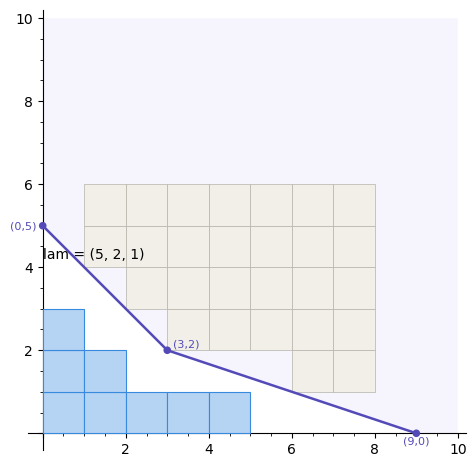

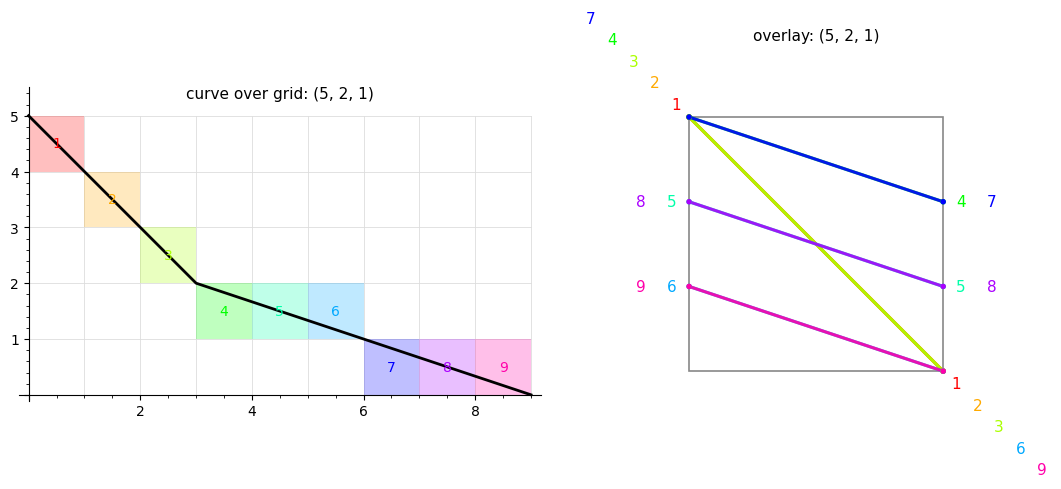

Braid word: [4, 5, 6, 7, 1, 2, 3, 8, 9]
List1: [0, 0, 0, 0, 1, 0, 0, 0, 0]
List2: [0, 0, 0, 0, 1]


In [3]:
#GETTING THE BRAID WORD AND THE TWO 0/1 SEQUENCES FOR A GIVEN PARTITION

partition = [5,2,1] #partition in french notation
details = concave_hull(partition, True) #get the details of the concave hull, True means we want to plot the concave hull
b_word = boundary_permutation(details, True) #get the braid word, True means we want to plot overlay
print("Braid word:", b_word)
l1, l2 = torus_sequences(details) #get the two 0/1 sequences
print("List1:", l1)
print("List2:", l2)

Torus Knot (braid polynomial):
  Term 0: coeff=1, list1=[0, 0, 0, 0, 1, 0, 0, 0, 0], list2=[0, 0, 0, 0, 1], word=[4, 3, 2, 1, 5, 4, 3, 2, 6, 5, 4, 3]
TorusKnot(list1=[0, 0, 0, 0, 1, 0, 0, 0, 0], list2=[0, 0, 0, 0, 1], braid=(1)*[s3*s2*s1*s0*s4*s3*s2*s1*s5*s4*s3*s2])
Before simplify: Torus Knot (braid polynomial):
  Term 0: coeff=1, list1=[0, 0, 0, 0, 1, 0, 0, 0, 0], list2=[0, 0, 0, 0, 1], word=[4, 3, 2, 1, 5, 4, 3, 2, 6, 5, 4, 3]


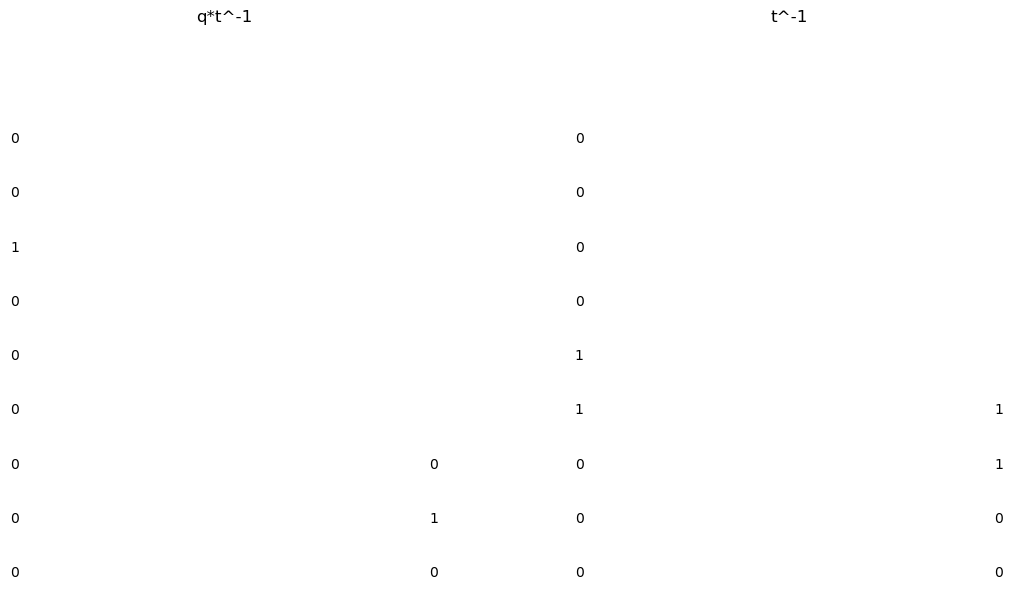

In [4]:
#SIMPLIFYING THE TORUS KNOT USING THE SIMPLIFICATION RULES
tk = TorusKnot(l1, l2, b_word, window=True) #b_word is window notation (a permutation); window=True converts it to a braid word
print(tk) #print the TorusKnot object
print(repr(tk)) #repr(tk) gives a more detailed representation of the TorusKnot object

import matplotlib.pyplot as plt
import math

# Grid layout: set ncols to the width you want; nrows grows to fit npanels.
#npanels = 5
#ncols = 2
#nrows = math.ceil(npanels / ncols)
#fig, axes = plt.subplots(nrows, ncols, figsize=(6 * ncols, 6 * nrows), squeeze=False)
#axes = axes.flatten()


print("Before simplify:", tk)
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_1_on_top()
#tk.plot_braid()

tk.simplify_0s_vertical()
#tk.plot_braid()

tk.simplify_0s_vertical()
#tk.plot_braid()

tk.simplify_0s_vertical()
#tk.plot_braid()

tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.simplify_0s_vertical()
tk.simplify_10_first()
tk.simplify_1_on_top()
tk.simplify_1_on_top()
tk.simplify_1_on_top()
tk.simplify_1_on_top()
tk.simplify_0s_first()
tk.simplify_0s_vertical(term=0)
tk.simplify_1_on_top(term=1)
tk.simplify_0s_vertical(term=0)
tk.simplify_1_on_top(term=1)
tk.simplify_0s_vertical(term=0)
tk.simplify_1_on_top(term=1)
tk.simplify_0s_vertical(term=0)
tk.simplify_1_on_top(term=1)
tk.simplify_top_edge(term=0)
tk.simplify_top_edge(term=0)
tk.move_letter_to_front(letter=3, term=0)
tk.simplify_1_on_top(term=0)
tk.simplify_1_on_top(term=0)
tk.simplify_1_on_top(term=0)
tk.simplify_10_first(term=0)
tk.simplify_1_on_top(term=0)
tk.simplify_1_on_top(term=0)

tk.plot_braid()

In [5]:
# ============================================================
#  AUTOMATIC SIMPLIFICATION
#
#  solve_partition(lam) does the whole pipeline in one call:
#      partition -> concave hull -> window permutation + 0/1 sequences
#               -> TorusKnot     -> repeatedly apply the simplification rules
#                                   until every braid word is empty.
#
#  A term is "done" when its braid word is empty (no crossings left); the
#  knot is solved when every term of the braid polynomial is done.
#
#  Rules are tried in the order below and the search backtracks whenever a
#  branch dies, so the splitting rule (simplify_0s_first, the only rule that
#  turns one braid into two) is used only if no other route finishes.
# ============================================================

import io
import contextlib

# Rule priority: earlier = tried first.
DEFAULT_PRIORITY = [
    'simplify_1_on_top',      # removes a crossing outright  -- always preferred
    'simplify_0s_vertical',   # slides a 0/0 crossing around to the far side
    'simplify_top_edge',      # re-inserts an unlabeled crossing on the right
    'simplify_10_first',      # removes an uncrossed 1|0 strand
    'simplify_01_first',      # removes an uncrossed 0|1 strand
    'move_letter_to_front',   # rewrite the word to start with a chosen letter
    'simplify_0s_first',      # LAST RESORT: splits one braid into two
]


# ── term bookkeeping ─────────────────────────────────────────

def _copy_term(term):
    return {'coeff': term['coeff'],
            'list1': list(term['list1']),
            'list2': list(term['list2']),
            'word':  [int(g) for g in term['word']]}

def _term_sig(term):
    return (tuple(term['list1']), tuple(term['list2']), tuple(term['word']))


# ── applicability tests (mirror the rules; no printing, no mutation) ──
#
# `val` below is the value of the braid letter sitting at the front of the
# word: s_val crosses the strands at 0-based positions val-1 and val.

def _enables_1_on_top(term, val):
    l1 = term['list1']
    return val < len(l1) and l1[val] == 1

def _enables_0s_vertical(term, val):
    l1 = term['list1']
    return val < len(l1) and l1[val - 1] == 0 and l1[val] == 0

def _enables_top_edge(term, val):
    l1, l2 = term['list1'], term['list2']
    if val <= len(l1):
        return False
    k = val - len(l1) - 1
    return sum(1 for v in l2 if v == 0) >= k + 2

def _no_s1(term):
    return not any(abs(int(g)) == 1 for g in term['word'])

def _can_1_on_top(term):
    return bool(term['word']) and _enables_1_on_top(term, abs(int(term['word'][0])))

def _can_0s_vertical(term):
    return bool(term['word']) and _enables_0s_vertical(term, abs(int(term['word'][0])))

def _can_top_edge(term):
    return bool(term['word']) and _enables_top_edge(term, abs(int(term['word'][0])))

def _can_10_first(term):
    l1, l2 = term['list1'], term['list2']
    return bool(l1) and bool(l2) and l1[0] == 1 and l2[0] == 0 and _no_s1(term)

def _can_01_first(term):
    l1, l2 = term['list1'], term['list2']
    return bool(l1) and bool(l2) and l1[0] == 0 and l2[0] == 1 and _no_s1(term)

def _can_0s_first(term):
    l1, l2 = term['list1'], term['list2']
    return bool(l1) and bool(l2) and l1[0] == 0 and l2[0] == 0 and _no_s1(term)


def _reorder_letters(term):
    """Braid letters worth asking move_letter_to_front about: the ones that
    would expose a usable crossing if the word could be rewritten to start with
    them -- 1-on-top first, then the other two crossing rules.

    Only letters that already occur in the word can be pulled to the front of a
    positive braid, and each distinct letter is asked about once no matter how
    often it occurs.  move_letter_to_front may still say no; this only filters
    out the letters that are pointless to ask about."""
    word = term['word']
    front = abs(int(word[0])) if word else None
    tiers = ([], [], [])
    seen = set()
    for g in word:
        val = abs(int(g))
        if val == front or val in seen:
            continue                       # front letter: nothing new is exposed
        seen.add(val)
        if _enables_1_on_top(term, val):
            tiers[0].append(val)
        elif _enables_0s_vertical(term, val):
            tiers[1].append(val)
        elif _enables_top_edge(term, val):
            tiers[2].append(val)
    return tiers[0] + tiers[1] + tiers[2]


def _candidate_moves(term, priority):
    """The moves available at `term`, in priority order."""
    moves = []
    for name in priority:
        if name == 'move_letter_to_front':
            moves += [(name, {'letter': g}) for g in _reorder_letters(term)]
        elif name == 'simplify_1_on_top'    and _can_1_on_top(term):    moves.append((name, {}))
        elif name == 'simplify_0s_vertical' and _can_0s_vertical(term): moves.append((name, {}))
        elif name == 'simplify_top_edge'    and _can_top_edge(term):    moves.append((name, {}))
        elif name == 'simplify_10_first'    and _can_10_first(term):    moves.append((name, {}))
        elif name == 'simplify_01_first'    and _can_01_first(term):    moves.append((name, {}))
        elif name == 'simplify_0s_first'    and _can_0s_first(term):    moves.append((name, {}))
    return moves


# ── the search ───────────────────────────────────────────────

# move_letter_to_front runs a Garside normal form, which is by far the most
# expensive thing here, and the search meets the same (word, letter) pair on
# many branches.  Its result depends only on the word, the strand count and the
# letter, so it is worth caching.
_MLF_CACHE = {}

def _apply_move(work, term, name, kwargs):
    """Run one rule on a copy of `term`, using `work` (a TorusKnot) purely as
    the host object the rule methods need.  Returns the resulting list of terms
    (two of them for the splitting rule) or None if the rule refused."""
    key = None
    if name == 'move_letter_to_front':
        n = len(term['list1']) + len(term['list2']) - sum(term['list2'])
        key = (tuple(term['word']), n, kwargs['letter'])
        if key in _MLF_CACHE:
            word = _MLF_CACHE[key]
            if word is None:
                return None
            out = _copy_term(term)
            out['word'] = list(word)
            return [out]

    work.terms = [_copy_term(term)]
    buf = io.StringIO()
    try:
        with contextlib.redirect_stdout(buf):
            ok = getattr(work, name)(term=0, **kwargs)
    except Exception:
        ok = False

    if key is not None:
        _MLF_CACHE[key] = tuple(work.terms[0]['word']) if ok else None
    if not ok:
        return None
    return [_copy_term(t) for t in work.terms]


def _solve_term(work, term, label, priority, dead, path, max_word, budget, steps):
    """Depth-first search for a sequence of rules that empties `term`'s braid
    word.  On success returns the finished term(s) and appends the winning
    moves to `steps`; on failure returns None and leaves `steps` untouched."""
    if not term['word']:
        return [term]                                   # solved: no crossings left

    if len(term['word']) > max_word or budget['nodes'] <= 0:
        return None
    sig = _term_sig(term)
    if sig in dead or sig in path:                      # already refuted, or a cycle
        return None
    budget['nodes'] -= 1
    path.add(sig)

    for name, kwargs in _candidate_moves(term, priority):
        res = _apply_move(work, term, name, kwargs)
        if res is None:
            continue
        branch = [(label, name, kwargs, res)]

        if len(res) == 1:                               # ordinary rule
            done = _solve_term(work, res[0], label, priority,
                               dead, path, max_word, budget, branch)
        else:                                           # the split: solve both halves
            done = []
            for k, child in enumerate(res):
                sub = _solve_term(work, child, '{}.{}'.format(label, k), priority,
                                  dead, path, max_word, budget, branch)
                if sub is None:
                    done = None
                    break
                done += sub

        if done is not None:
            path.discard(sig)
            steps += branch
            return done

    path.discard(sig)
    if budget['nodes'] > 0:                             # a real refutation, not a timeout
        dead.add(sig)
    return None


def _fmt_step(i, label, name, kwargs, res):
    args = ', '.join('{}={}'.format(k, v) for k, v in kwargs.items())
    call = '{}({})'.format(name, args)
    head = '  {:>3}. [{}] {:<38}'.format(i, label, call)
    if len(res) == 2:
        return head + ' -> split into [{}.0] and [{}.1]'.format(label, label)
    t = res[0]
    return head + ' l1={} l2={} word={}'.format(t['list1'], t['list2'], t['word'])


# ── drawing the whole reduction ──────────────────────────────

def _solution_panels(start, steps):
    """One (title, term) pair per braid to draw: the starting braid(s), then the
    state after each move of the winning sequence.  A split contributes two
    panels, one for each new term."""
    panels = [('start [{}]'.format(k), t) for k, t in enumerate(start)]
    for i, (label, name, kwargs, res) in enumerate(steps, start=1):
        args = ', '.join('{}={}'.format(k, v) for k, v in kwargs.items())
        rule = name[len('simplify_'):] if name.startswith('simplify_') else name
        head = '{}. [{}] {}({})'.format(i, label, rule, args)
        if len(res) == 2:                       # the split: draw both halves
            panels.append(('{} -> [{}.0]'.format(head, label), res[0]))
            panels.append(('{} -> [{}.1]'.format(head, label), res[1]))
        else:
            panels.append((head, res[0]))
    return panels


def plot_solution(tk, start, steps, ncols=4, size=3.4, max_panels=80):
    """Draw the braid at every stage of the reduction, in move order.

    Each panel is titled with the rule that produced it and the term it left
    behind, so the whole run can be read straight off the picture.  Only the
    moves that actually led to the solution are drawn -- the branches the search
    tried and abandoned are not.  Long runs are cut off at `max_panels`.
    """
    import math
    import matplotlib.pyplot as plt

    panels = _solution_panels(start, steps)
    if len(panels) > max_panels:
        print('{} panels to draw; showing the first {}. Raise max_panels for the rest.'
              .format(len(panels), max_panels))
        panels = panels[:max_panels]

    ncols = min(ncols, len(panels))
    nrows = math.ceil(len(panels) / ncols)
    fig, axes = plt.subplots(nrows, ncols, figsize=(size * ncols, size * nrows),
                             squeeze=False)
    axes = axes.flatten()

    def _bits(lst):                        # [0,0,1,0] -> '0010', so titles stay narrow
        return ''.join(str(int(x)) for x in lst)

    for (title, term), ax in zip(panels, axes):
        tk._plot_one(term, ax=ax)          # an empty word draws as uncrossed strands
        ax.set_title('{}\ncoeff = {}\nlist1 {}   list2 {}'.format(
            title, term['coeff'], _bits(term['list1']), _bits(term['list2'])),
            fontsize=7)
        ax.axis('off')
    for ax in axes[len(panels):]:
        ax.axis('off')
    plt.tight_layout(h_pad=2.2)
    plt.show()


def auto_simplify(tk, priority=None, max_nodes=20000, max_word=None, verbose=True, plot=False):
    """Simplify a TorusKnot until every term's braid word is empty.

    Applies the rules in `priority` order, backtracking when a branch dies, so
    simplify_0s_first (the rule that splits one braid into two) is only used
    where nothing else finishes the job.  `tk` is rewritten in place with the
    finished terms.  Returns True if every term was solved.

    With plot=True the braid is drawn after every move of the winning sequence.
    The run is also kept on the knot as tk.solution = {'start':..., 'steps':...},
    so it can be redrawn later with plot_solution(tk, **tk.solution).
    """
    priority = list(priority) if priority else list(DEFAULT_PRIORITY)
    if max_word is None:
        max_word = max(4 * max(len(t['word']) for t in tk.terms), 40)

    budget = {'nodes': max_nodes}
    dead, steps, solved = set(), [], []

    # The rules are run through `tk` itself, which overwrites tk.terms, so work
    # from a snapshot and only install the result once every term is solved.
    start = [_copy_term(t) for t in tk.terms]

    for k, term in enumerate(start):
        done = _solve_term(work=tk, term=_copy_term(term), label=str(k), priority=priority,
                           dead=dead, path=set(), max_word=max_word,
                           budget=budget, steps=steps)
        if done is None:
            tk.terms = start                                 # leave tk as it was
            if verbose:
                if budget['nodes'] <= 0:
                    print('Gave up on term {}: search budget ({} nodes) exhausted. '
                          'Try a bigger max_nodes, or a different `priority` order.'.format(k, max_nodes))
                else:
                    print('Term {} cannot be finished: no sequence of these rules empties its '
                          'braid word.'.format(k))
            return False
        solved += done

    tk.terms = solved
    tk.solution = {'start': start, 'steps': steps}

    if verbose:
        for i, s in enumerate(steps, start=1):
            print(_fmt_step(i, *s))
        print('\nSolved in {} moves; braid polynomial has {} term(s), all with empty braid words:'
              .format(len(steps), len(tk.terms)))
        for k, t in enumerate(tk.terms):
            print('  term {}: coeff={:<12} list1={} list2={}'.format(k, str(t['coeff']), t['list1'], t['list2']))

    if plot:
        plot_solution(tk, start, steps)
    return True


def solve_partition(lam, plot=False, verbose=True, priority=None, max_nodes=20000):
    """Partition -> torus knot -> fully simplified braid polynomial, in one call.

    lam       : partition in French notation, e.g. [5,2,1]
    plot      : draw the concave hull, the overlay, and the braid after every
                move of the reduction (not just the final one)
    priority  : rule order to try (defaults to DEFAULT_PRIORITY)
    max_nodes : search budget; raise it for partitions that need many splits

    Returns the solved TorusKnot (or None if the partition yields no curve).

    Every partition of size <= 9 solves.  The tall hook-like ones need several
    splits and a lot of searching: [3,1,1,1,1,1,1] wants max_nodes=150000 and
    takes about a minute, and its neighbours take tens of seconds.  If a solve
    reports the budget was exhausted, raise max_nodes.
    """
    details = concave_hull(lam, plot=plot, verbose=verbose)
    l1, l2 = torus_sequences(details)
    if not l1 or not l2:
        print('Partition {}: no curve, nothing to solve.'.format(list(lam)))
        return None

    perm = boundary_permutation(details, plot=plot)
    tk = TorusKnot(l1, l2, perm, window=True)

    if verbose:
        print('partition   {}'.format(list(lam)))
        print('window perm {}'.format(perm))
        print('list1       {}'.format(l1))
        print('list2       {}'.format(l2))
        print('braid word  {}\n'.format(tk.braid_word))

    auto_simplify(tk, priority=priority, max_nodes=max_nodes, verbose=verbose, plot=plot)
    return tk

Partition [5, 2, 1] is concave.
Finite vertices of the unbounded convex hull: [(1, 4), (3, 2), (6, 1)]


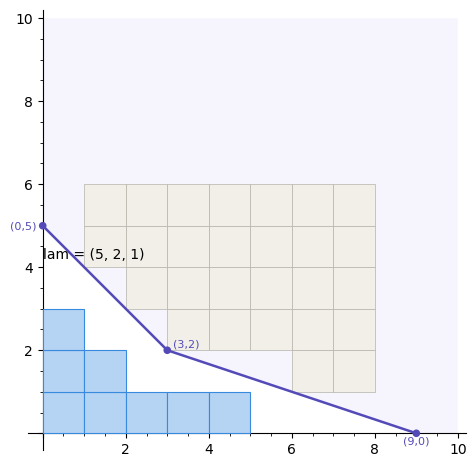

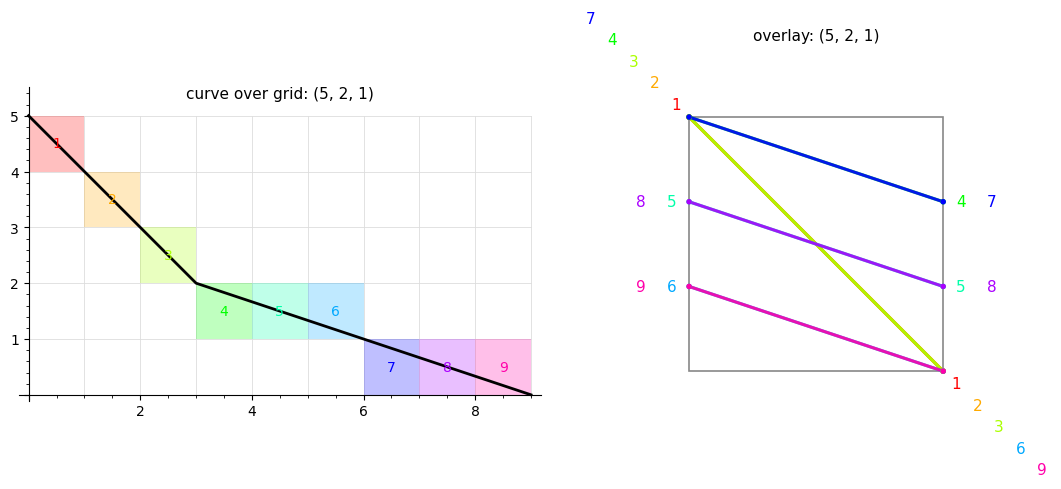

partition   [5, 2, 1]
window perm [4, 5, 6, 7, 1, 2, 3, 8, 9]
list1       [0, 0, 0, 0, 1, 0, 0, 0, 0]
list2       [0, 0, 0, 0, 1]
braid word  [4, 3, 2, 1, 5, 4, 3, 2, 6, 5, 4, 3]

    1. [0] simplify_1_on_top()                    l1=[0, 0, 0, 1, 0, 0, 0, 0, 0] l2=[0, 0, 0, 0, 1] word=[3, 2, 1, 5, 4, 3, 2, 6, 5, 4, 3]
    2. [0] simplify_1_on_top()                    l1=[0, 0, 1, 0, 0, 0, 0, 0, 0] l2=[0, 0, 0, 0, 1] word=[2, 1, 5, 4, 3, 2, 6, 5, 4, 3]
    3. [0] simplify_1_on_top()                    l1=[0, 1, 0, 0, 0, 0, 0, 0, 0] l2=[0, 0, 0, 0, 1] word=[1, 5, 4, 3, 2, 6, 5, 4, 3]
    4. [0] simplify_1_on_top()                    l1=[1, 0, 0, 0, 0, 0, 0, 0, 0] l2=[0, 0, 0, 0, 1] word=[5, 4, 3, 2, 6, 5, 4, 3]
    5. [0] simplify_0s_vertical()                 l1=[1, 0, 0, 0, 0, 0, 0, 0, 0] l2=[0, 0, 0, 0, 1] word=[4, 3, 2, 6, 5, 4, 3, 9]
    6. [0] simplify_0s_vertical()                 l1=[1, 0, 0, 0, 0, 0, 0, 0, 0] l2=[0, 0, 0, 0, 1] word=[3, 2, 6, 5, 4, 3, 9, 8]
    7. [0] simplify_0s

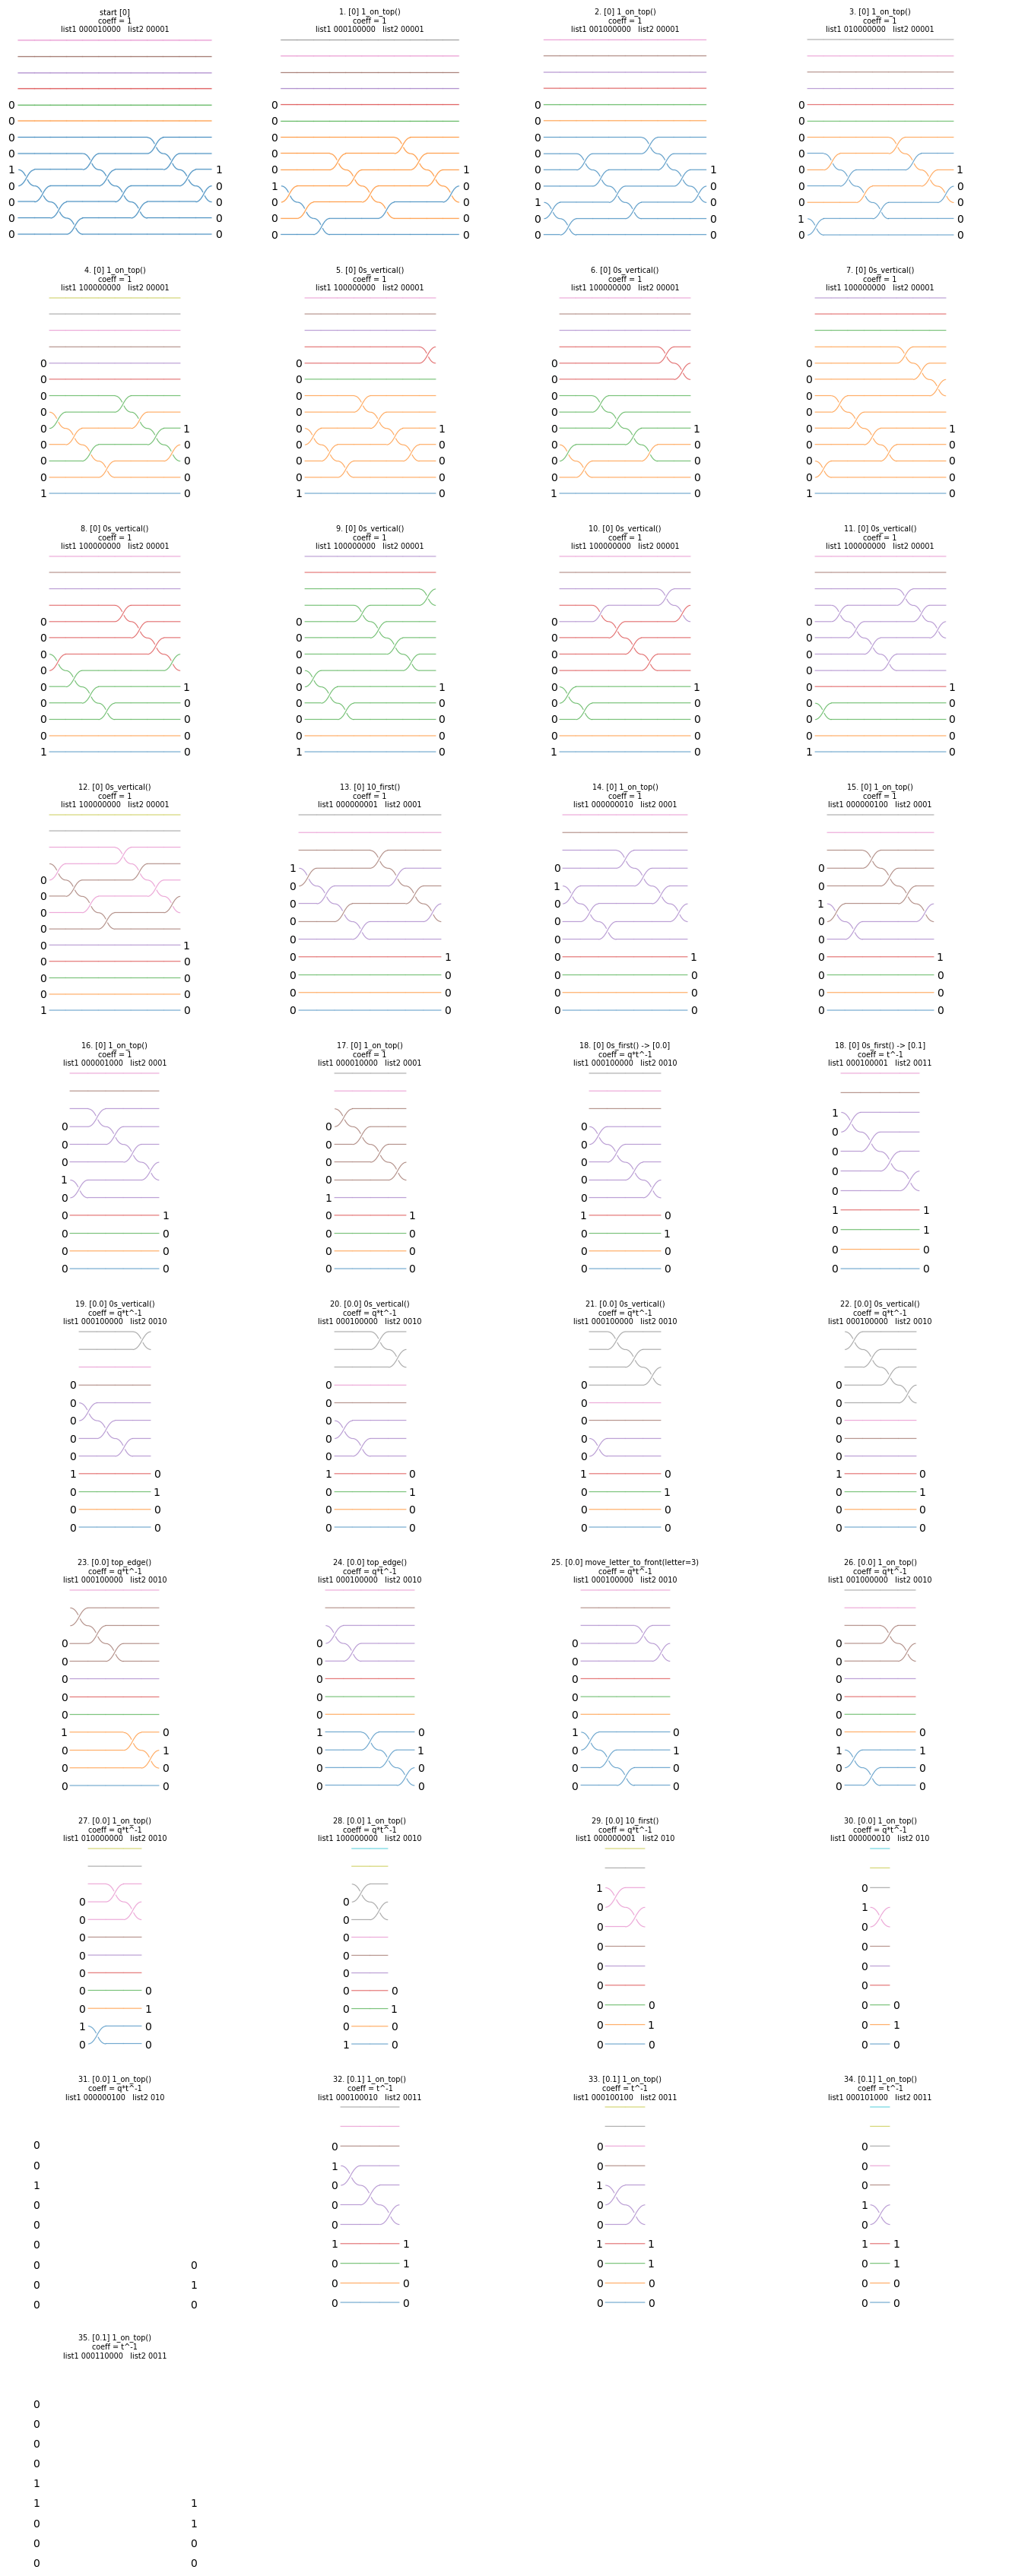

In [6]:
#AUTOMATED SOLVE: partition in, fully simplified braid polynomial out.
#Rules are tried in priority order (1-on-top first) and the search backtracks,
#so the braid is only split (simplify_0s_first) when nothing else finishes it.

#plot=True draws the concave hull, the overlay, and the braid after EVERY move
#of the reduction, each panel titled with the rule that produced it.
tk = solve_partition([5,2,1], plot=True)

#Other things to try:
#solve_partition([3,2,1], plot=True)          # solves without ever splitting
#solve_partition([5,2,1], plot=False)         # log only, no pictures
#solve_partition([5,2,1], verbose=False)      # no move-by-move log
#solve_partition([3,1,1,1,1,1,1], max_nodes=150000)   # needs a bigger budget

#The winning run is kept on the knot, so you can redraw it (or part of it) later:
#plot_solution(tk, ncols=6, size=2.6, **tk.solution)
